In [ ]:
# %% [0] 5회차 실습 노트북 시작: 분포/정규분포/왜도/첨도/PDF/경험적vs이론적/이상치/Q-Q plot
# Google Colab에서 그대로 실행할 수 있도록 작성했습니다.
# 목표:
# 1) "데이터는 숫자 하나가 아니라 모양(분포)이다"를 체감한다.
# 2) 정규분포는 '현실'이 아니라 '모델(근사)'임을 이해한다.
# 3) 왜도/첨도/이상치가 평균·표준편차·해석을 어떻게 흔드는지 눈으로 확인한다.
# 4) PDF(확률밀도)와 "확률=면적" 개념을 히스토그램과 연결한다.
# 5) Q-Q plot으로 경험적 분포와 이론적 분포를 비교하는 관점을 만든다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 기본 설정(보기 좋게)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

# 재현성(수업에서 동일한 결과를 보여주기 위해)
np.random.seed(42)


# %% [1] 도우미 함수: 분포를 "그림 + 숫자"로 함께 보는 습관 만들기
# 왜 도우미가 필요한가?
# - 초심자는 그래프만 보면 '감'으로 끝나기 쉽고,
# - 숫자만 보면 '요약값'에 속기 쉽습니다.
# 그래서 "그래프(모양) + 핵심 요약(평균/중앙값/표준편차/왜도/첨도)"를 항상 같이 봅니다.

def summary_stats(x):
    """
    x: 1차원 배열(리스트/넘파이)
    반환: 평균, 중앙값, 표본 표준편차, 왜도, (초과)첨도 등
    - scipy 없이도 계산 가능하도록 직접 계산합니다.
    - 여기의 왜도/첨도는 '개념 이해'를 위한 지표로 사용합니다(정밀 검정 목적 아님).
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    n = len(x)
    mean = np.mean(x)
    median = np.median(x)
    std = np.std(x, ddof=1)  # 표본 표준편차

    # 왜도(skewness): 3차 중심모멘트 / 표준편차^3
    # 직관: 꼬리가 한쪽으로 길면 평균이 그쪽으로 끌려가고, 왜도가 생깁니다.
    m3 = np.mean((x - mean) ** 3)
    skew = m3 / (np.std(x, ddof=0) ** 3 + 1e-12)

    # 첨도(kurtosis)와 초과 첨도(excess kurtosis)
    # 첨도는 '뾰족함'이 아니라, 꼬리/극단값에 대한 민감도(heavy tail) 관점이 핵심입니다.
    m4 = np.mean((x - mean) ** 4)
    kurt = m4 / (np.std(x, ddof=0) ** 4 + 1e-12)
    kurt_excess = kurt - 3  # 정규분포 기준(초과 첨도)

    # 사분위수/ IQR(이상치 판단과 분포 폭 해석에 유용)
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1

    return {
        "n": int(n),
        "mean": float(mean),
        "median": float(median),
        "std(sample)": float(std),
        "skew": float(skew),
        "kurtosis_excess": float(kurt_excess),
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
    }


def normal_pdf(xs, mu, sigma):
    """
    정규분포 확률밀도함수(PDF)
    - PDF의 '높이'는 확률이 아닙니다.
    - 특정 구간의 확률은 PDF 곡선 아래 '면적'입니다.
    """
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)


def plot_hist_with_pdf_overlay(x, title, bins=30, overlay_normal=True):
    """
    히스토그램(경험적 분포) + (선택) 정규분포 PDF(이론적 분포) 곡선 겹치기
    핵심:
    - density=True를 쓰면, 히스토그램의 전체 면적이 1이 됩니다.
    - 그 위에 PDF 곡선을 겹치면, '확률=면적' 관점으로 비교가 가능합니다.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    stats = summary_stats(x)
    mu = stats["mean"]
    sigma = stats["std(sample)"]

    plt.figure(figsize=(7, 4))
    plt.hist(x, bins=bins, density=True, alpha=0.75)  # density=True: 확률 "밀도" 스케일

    if overlay_normal:
        xs = np.linspace(np.min(x), np.max(x), 400)
        plt.plot(xs, normal_pdf(xs, mu, sigma), linewidth=2)

    plt.title(title)
    plt.xlabel("value")
    plt.ylabel("density")

    # 그래프 아래에 핵심 요약을 표시(수업 중 '말로 해석' 훈련에 도움)
    text = (
        f"n={stats['n']} | mean={stats['mean']:.2f} | median={stats['median']:.2f} | std={stats['std(sample)']:.2f}\n"
        f"skew={stats['skew']:.2f} | kurt_excess={stats['kurtosis_excess']:.2f} | IQR={stats['iqr']:.2f}"
    )
    plt.gcf().text(0.12, -0.18, text, fontsize=10)
    plt.tight_layout()
    plt.show()


def approx_mode_from_hist(x, bins=30):
    """
    연속형 데이터에서 '최빈값(mode)'은 애매할 수 있습니다.
    - 연속형 값은 동일한 값이 반복되지 않는 경우가 많아 '정확한 최빈값'이 정의되기 어렵습니다.
    - 그래서 히스토그램에서 가장 높은 막대 구간의 중앙값을 "근사 최빈값"으로 사용합니다.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    counts, edges = np.histogram(x, bins=bins)
    idx = np.argmax(counts)
    left, right = edges[idx], edges[idx + 1]
    return (left + right) / 2



In [ ]:

# %% [2] 분포(distribution) 첫 체감: "같은 평균, 다른 분포"
# 왜 중요한가?
# - 평균은 한 점(요약 숫자)입니다.
# - 분포는 데이터 전체의 얼굴(모양)입니다.
# 평균이 같아도 현실이 완전히 달라질 수 있습니다.


n = 5000
mu = 70

# 같은 평균, 다른 표준편차(퍼짐)
A = np.random.normal(mu, 5, n)   # 촘촘
B = np.random.normal(mu, 20, n)  # 넓게

plot_hist_with_pdf_overlay(A, "A: Normal(mean=70, std=5)  (same mean, tighter)", bins=40, overlay_normal=True)
plot_hist_with_pdf_overlay(B, "B: Normal(mean=70, std=20) (same mean, wider)", bins=40, overlay_normal=True)

print("A stats:", summary_stats(A))
print("B stats:", summary_stats(B))


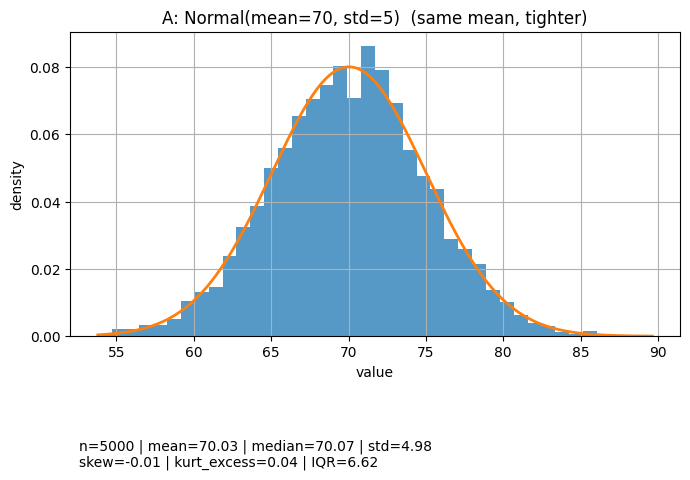

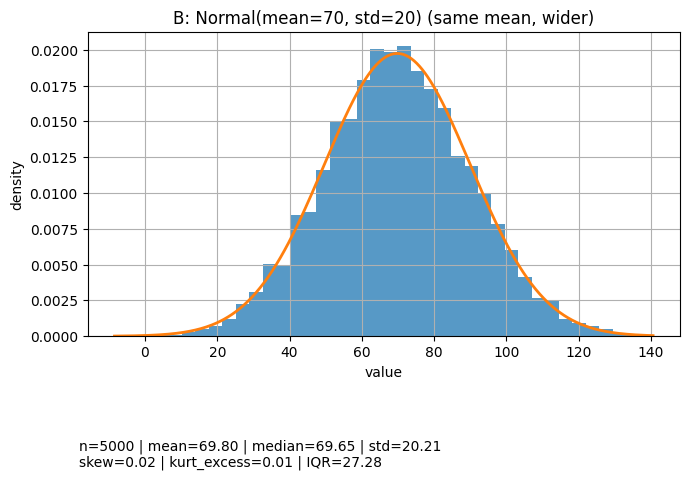

A stats: {'n': 5000, 'mean': 70.02800965043787, 'median': 70.06732795947713, 'std(sample)': 4.982399144104693, 'skew': -0.011928650210724244, 'kurtosis_excess': 0.04024425766301887, 'q1': 66.71047481171041, 'q3': 73.33005303525863, 'iqr': 6.619578223548217}
B stats: {'n': 5000, 'mean': 69.80252206351149, 'median': 69.65098948507818, 'std(sample)': 20.208741692596636, 'skew': 0.015918698820682278, 'kurtosis_excess': 0.0131645162589904, 'q1': 56.26834198767699, 'q3': 83.54476131510846, 'iqr': 27.27641932743147}


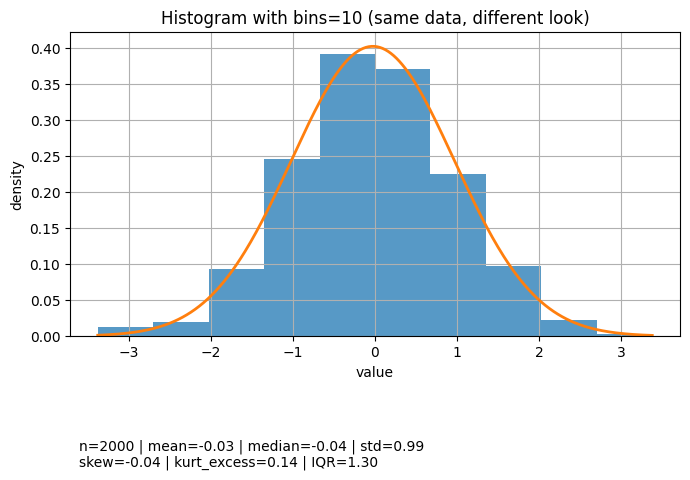

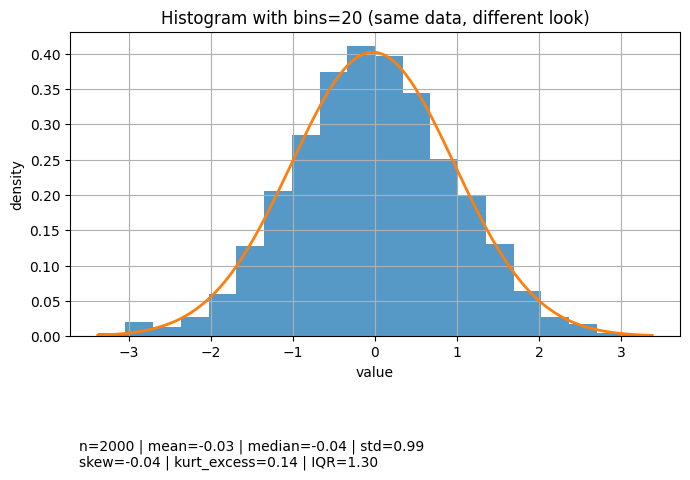

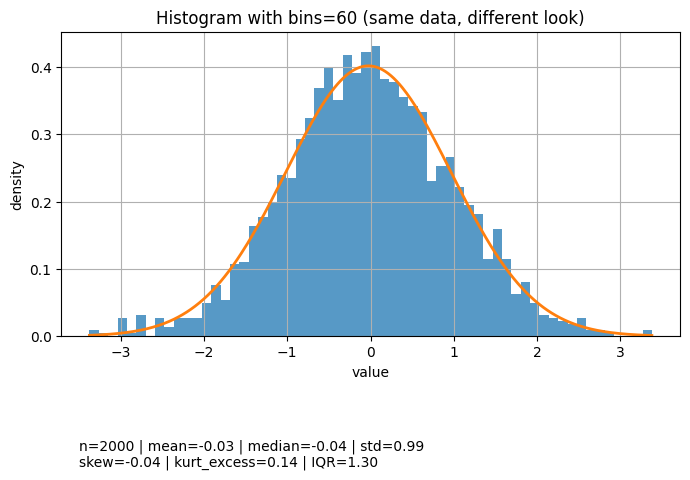

In [25]:

# %% [3] 히스토그램: bin 개수에 따라 '이야기'가 달라질 수 있다
# 왜 이걸 해야 하나?
# - 히스토그램은 사실을 보여주지만, bin 설정에 따라 착시도 만들 수 있습니다.
# - 따라서 분포를 볼 때는 bins를 바꿔가며 2~3번 확인하는 습관이 좋습니다.

X = np.random.normal(0, 1, 2000)

for bins in [10, 20, 60]:
    plot_hist_with_pdf_overlay(X, f"Histogram with bins={bins} (same data, different look)", bins=bins, overlay_normal=True)


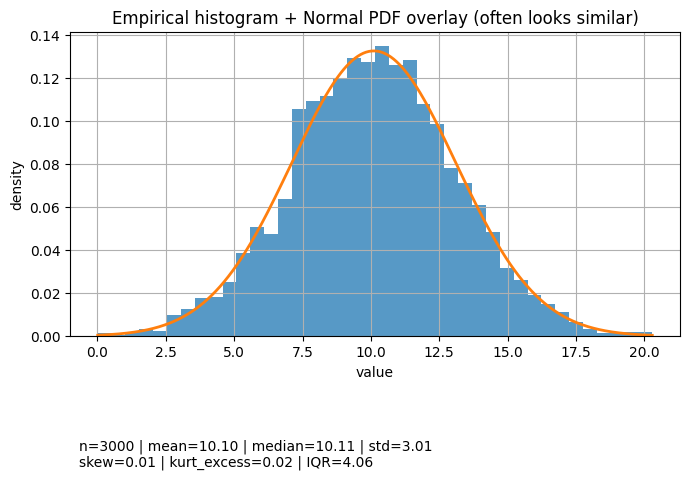

In [26]:


# %% [4] 정규분포(normal distribution): '현실'이 아니라 '모델(근사)'이다
# 핵심 메시지:
# - 경험적 분포: 실제 데이터로 만든 히스토그램(현실)
# - 이론적 분포: 정규분포 같은 수학적 모델(지도)
# 우리가 하는 일:
# - 정규분포가 "정답"인지 묻는 것이 아니라,
# - "정규분포로 근사해도 괜찮은가?"를 판단하는 것입니다.

real_like = np.random.normal(10, 3, 3000)
plot_hist_with_pdf_overlay(real_like, "Empirical histogram + Normal PDF overlay (often looks similar)", bins=40, overlay_normal=True)



[Normal-like] mean: 10.103867426768327
[Normal-like] median: 10.112022513939307
[Normal-like] approx mode: 10.402550556081989


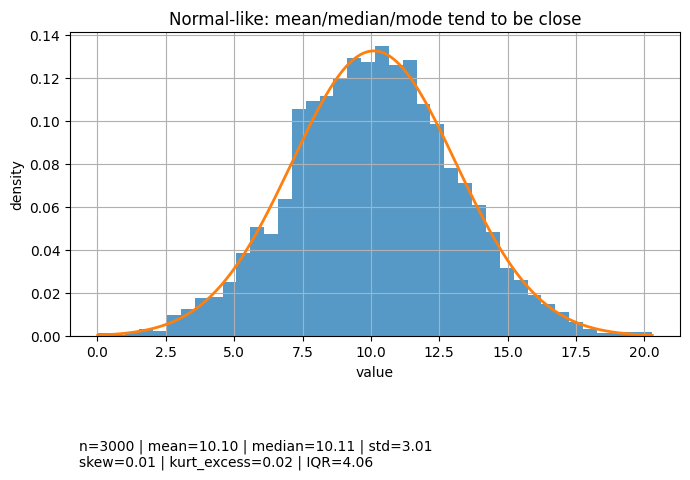

In [27]:

# %% [5] 평균·중앙값·최빈값: 대칭이면 모이고, 비대칭이면 갈라진다
# 초심자 질문:
# - '평균=중앙값=최빈값'은 왜 정규분포에서만 자주 말하나요?
# 답:
# - 핵심은 "대칭성"입니다.
#   대칭이면 중심이 하나로 모이고(세 값이 비슷),
#   비대칭이면 꼬리 방향으로 평균이 끌려가며(세 값이 갈라짐) 왜도가 생깁니다.

# (1) 정규에 가까운 분포: 대칭
stats_normal_like = summary_stats(real_like)
mode_normal_like = approx_mode_from_hist(real_like, bins=40)

print("[Normal-like] mean:", stats_normal_like["mean"])
print("[Normal-like] median:", stats_normal_like["median"])
print("[Normal-like] approx mode:", mode_normal_like)
plot_hist_with_pdf_overlay(real_like, "Normal-like: mean/median/mode tend to be close", bins=40, overlay_normal=True)



[Right-skew] mean: 8.928375769615949
[Right-skew] median: 7.4519496857554355
[Right-skew] approx mode: 6.221419242165622


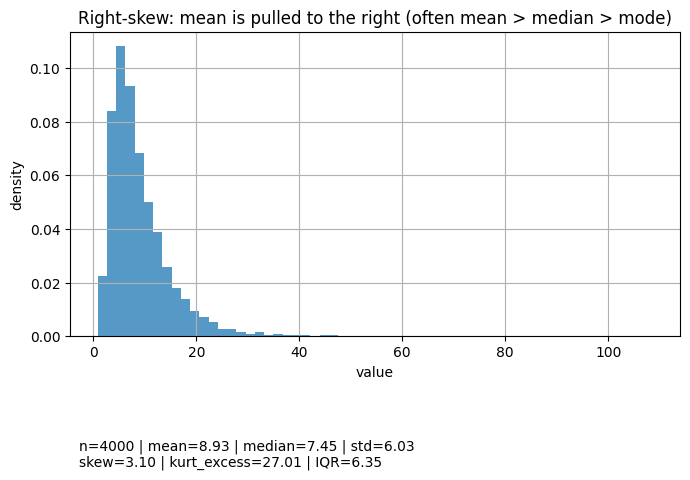

In [28]:

# (2) 오른쪽 왜도 분포: 비대칭
right_skew = np.random.lognormal(mean=2.0, sigma=0.6, size=4000)
stats_right = summary_stats(right_skew)
mode_right = approx_mode_from_hist(right_skew, bins=50)

print("\n[Right-skew] mean:", stats_right["mean"])
print("[Right-skew] median:", stats_right["median"])
print("[Right-skew] approx mode:", mode_right)
plot_hist_with_pdf_overlay(right_skew, "Right-skew: mean is pulled to the right (often mean > median > mode)", bins=60, overlay_normal=False)



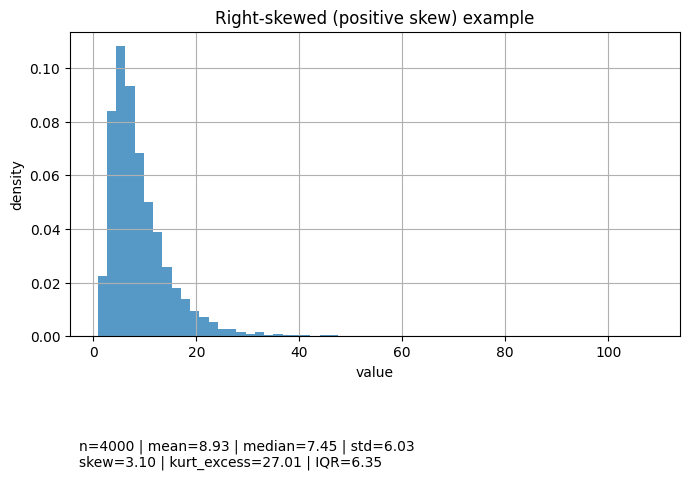

Right-skew stats: {'n': 4000, 'mean': 8.928375769615949, 'median': 7.4519496857554355, 'std(sample)': 6.0260557369133245, 'skew': 3.098950493461842, 'kurtosis_excess': 27.0095949230014, 'q1': 4.946673444544185, 'q3': 11.292622662611446, 'iqr': 6.345949218067261}


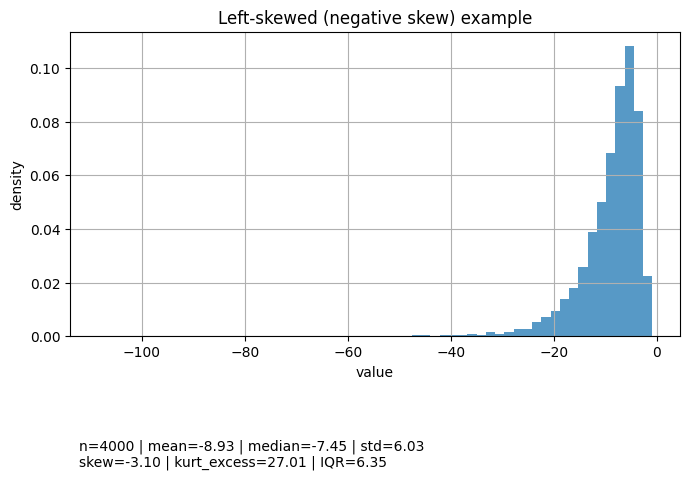

Left-skew stats: {'n': 4000, 'mean': -8.928375769615949, 'median': -7.4519496857554355, 'std(sample)': 6.0260557369133245, 'skew': -3.098950493461842, 'kurtosis_excess': 27.0095949230014, 'q1': -11.292622662611446, 'q3': -4.946673444544185, 'iqr': 6.345949218067261}


In [29]:

# %% [6] 왜도(skewness): "오른쪽/왼쪽"은 데이터가 많은 쪽이 아니라 '꼬리' 방향
# 초심자 오해:
# - "오른쪽 왜도 = 오른쪽에 데이터가 많다"?
# 정리:
# - 오른쪽 왜도(양의 왜도): 오른쪽 꼬리가 길다(극단적으로 큰 값이 조금 존재)
# - 왼쪽 왜도(음의 왜도): 왼쪽 꼬리가 길다(극단적으로 작은 값이 조금 존재)
#
# 실습 목표:
# - 왜도 부호(+, -)와 분포 모양을 연결한다.
# - 평균이 꼬리 방향으로 끌린다는 것을 확인한다.

# 왼쪽 왜도를 만들기 위한 간단한 방법:
# - 오른쪽 왜도 분포를 만들고, 부호를 뒤집어서 왼쪽으로 긴 꼬리를 만들 수 있습니다.
left_skew = -right_skew

plot_hist_with_pdf_overlay(right_skew, "Right-skewed (positive skew) example", bins=60, overlay_normal=False)
print("Right-skew stats:", summary_stats(right_skew))

plot_hist_with_pdf_overlay(left_skew, "Left-skewed (negative skew) example", bins=60, overlay_normal=False)
print("Left-skew stats:", summary_stats(left_skew))

# 핵심 확인:
# - right_skew는 skew가 양수로,
# - left_skew는 skew가 음수로 나오는지 봅니다.


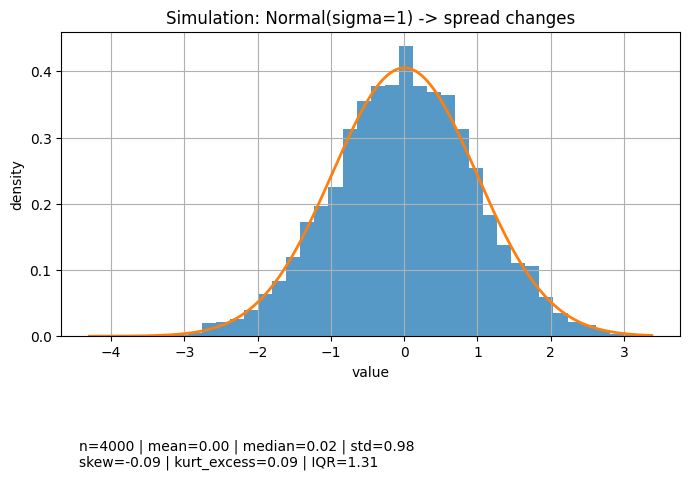

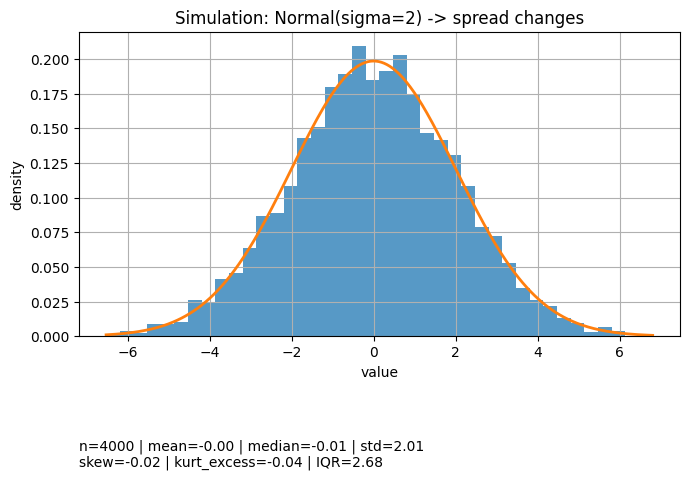

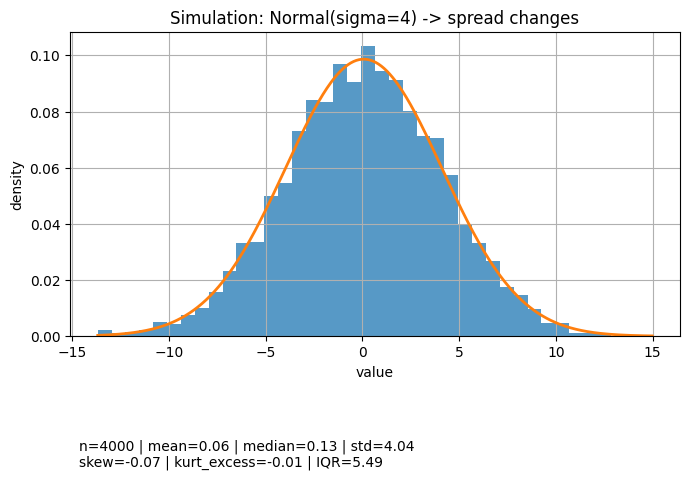

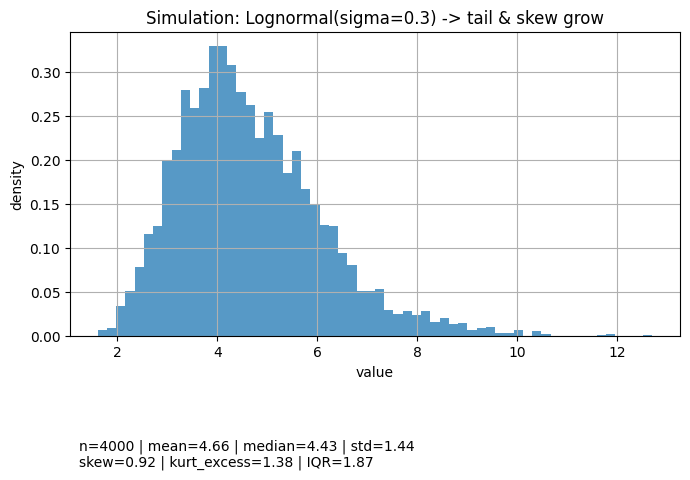

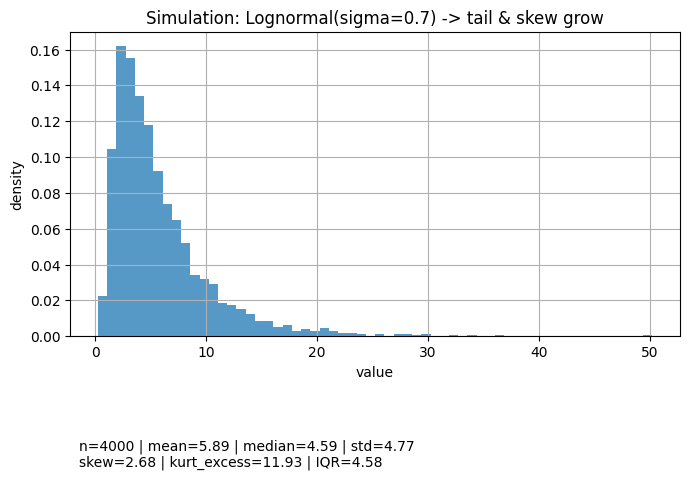

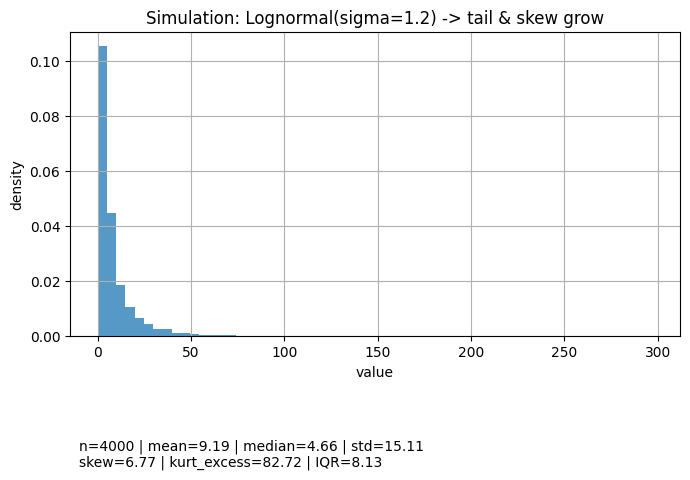

In [32]:


# %% [7] 분포 시뮬레이션: '만들어보면' 이해가 빨라진다
# 왜 시뮬레이션이 중요한가?
# - 통계 개념은 "정의"만 읽으면 손에 잡히지 않습니다.
# - 파라미터(평균/표준편차/꼬리)를 바꾸면 모양이 어떻게 변하는지 직접 보면,
#   이후 회귀/검정/변환이 자연스럽게 이어집니다.

# (1) 정규분포: 표준편차가 커지면 폭이 넓어진다
for s in [1, 2, 4]:
    data = np.random.normal(0, s, 4000)
    plot_hist_with_pdf_overlay(data, f"Simulation: Normal(sigma={s}) -> spread changes", bins=40, overlay_normal=True)

# (2) 로그정규: sigma가 커지면 꼬리/왜도가 급격히 커진다
for s in [0.3, 0.7, 1.2]:
    data = np.random.lognormal(mean=1.5, sigma=s, size=4000)
    plot_hist_with_pdf_overlay(data, f"Simulation: Lognormal(sigma={s}) -> tail & skew grow", bins=60, overlay_normal=False)



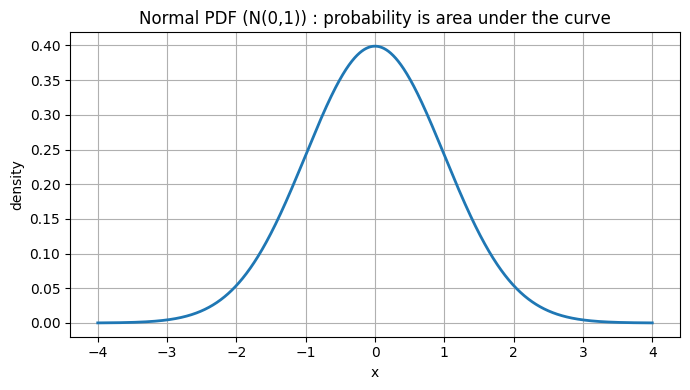

Approx P(-1 <= X <= 1) via area ~ 0.6819620259472099


In [33]:

# %% [8] 확률밀도(PDF): "확률은 높이가 아니라 면적"
# 초심자 질문:
# - "PDF가 높으면 확률이 높은 거 아닌가요?"
# 답:
# - 연속형에서는 '정확히 그 값'의 확률이 0이므로,
#   확률은 항상 '구간'으로 생각합니다.
# - PDF는 "근처에 얼마나 빽빽한가"를 나타내는 밀도입니다.
#
# 실습 목표:
# - 같은 정규분포에서, 특정 구간의 확률을 '면적(적분)'으로 근사해본다.
# - scipy 없이도 간단히 사다리꼴 적분(np.trapz)으로 면적을 근사할 수 있다.

mu, sigma = 0, 1
xs = np.linspace(-4, 4, 2000)
pdf = normal_pdf(xs, mu, sigma)

plt.figure(figsize=(7, 4))
plt.plot(xs, pdf, linewidth=2)
plt.title("Normal PDF (N(0,1)) : probability is area under the curve")
plt.xlabel("x")
plt.ylabel("density")
plt.tight_layout()
plt.show()

# 구간 확률 근사: P(-1 <= X <= 1)
mask = (xs >= -1) & (xs <= 1)
prob_approx = np.trapz(pdf[mask], xs[mask])  # 면적 근사
print("Approx P(-1 <= X <= 1) via area ~", prob_approx)

# 비교 실습:
# - mask 구간을 (-2,2), (-3,3)으로 바꾸면 확률이 커지는지 확인해보세요.


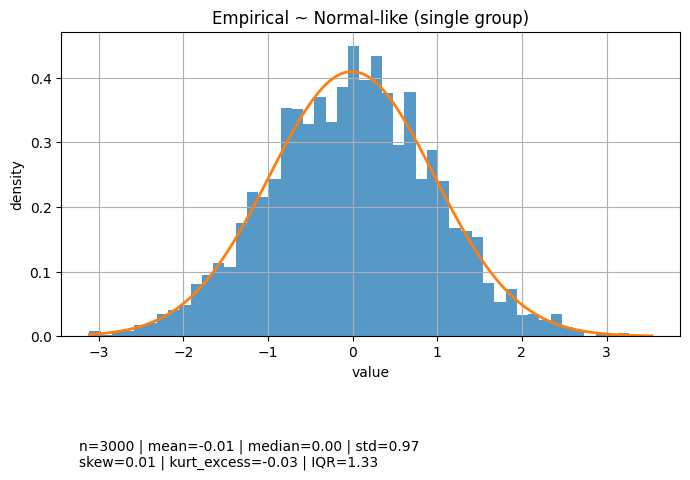

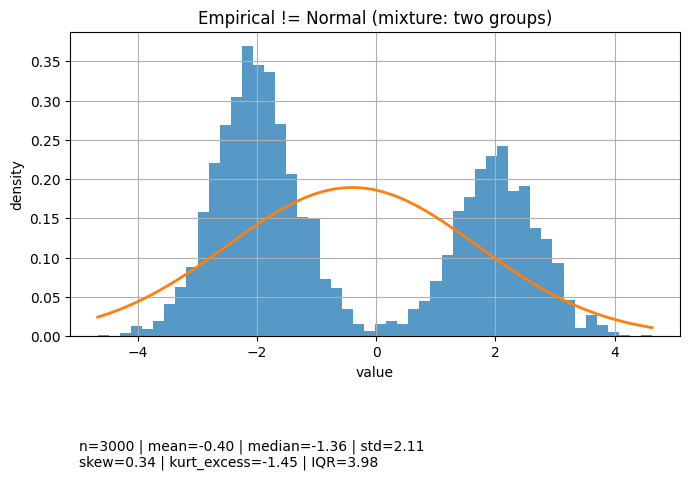

emp1 stats: {'n': 3000, 'mean': -0.007993442240348423, 'median': 0.0019973428212671208, 'std(sample)': 0.9732805204216112, 'skew': 0.009890397347950873, 'kurtosis_excess': -0.03329874049343173, 'q1': -0.6737362349576866, 'q3': 0.6569118088784869, 'iqr': 1.3306480438361734}
emp2 stats: {'n': 3000, 'mean': -0.4011503602631217, 'median': -1.363342830581662, 'std(sample)': 2.1074443535212852, 'skew': 0.34390566343437706, 'kurtosis_excess': -1.4502959970514724, 'q1': -2.172198658085522, 'q3': 1.8050145721445694, 'iqr': 3.9772132302300913}


In [34]:


# %% [9] 경험적 vs 이론적 분포: "현실(히스토그램) vs 모델(PDF 곡선)"
# 실습 목표:
# - 경험적 분포가 정규와 비슷한 경우 vs 다른 경우를 비교한다.
# - '비슷/다름'을 눈으로 말할 수 있게 한다.

# 경험적 분포가 정규와 비교적 비슷한 데이터
emp1 = np.random.normal(0, 1, 3000)

# 경험적 분포가 정규와 다르게 생긴 데이터(혼합 분포: 두 집단이 섞임)
emp2 = np.concatenate([
    np.random.normal(-2, 0.7, 1800),
    np.random.normal( 2, 0.7, 1200),
])

plot_hist_with_pdf_overlay(emp1, "Empirical ~ Normal-like (single group)", bins=50, overlay_normal=True)
plot_hist_with_pdf_overlay(emp2, "Empirical != Normal (mixture: two groups)", bins=50, overlay_normal=True)

print("emp1 stats:", summary_stats(emp1))
print("emp2 stats:", summary_stats(emp2))


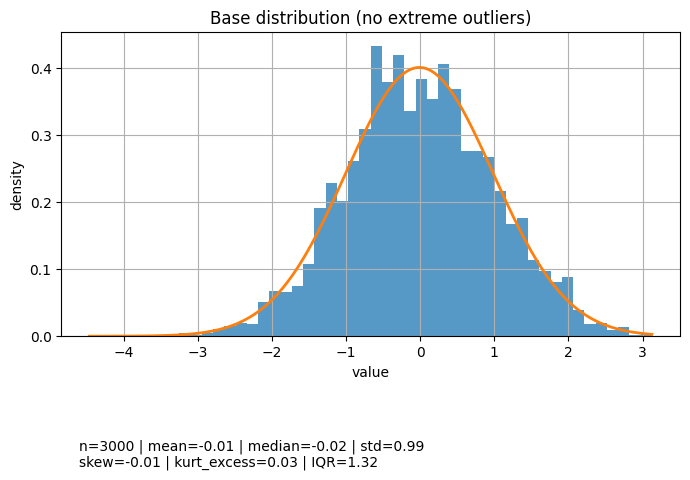

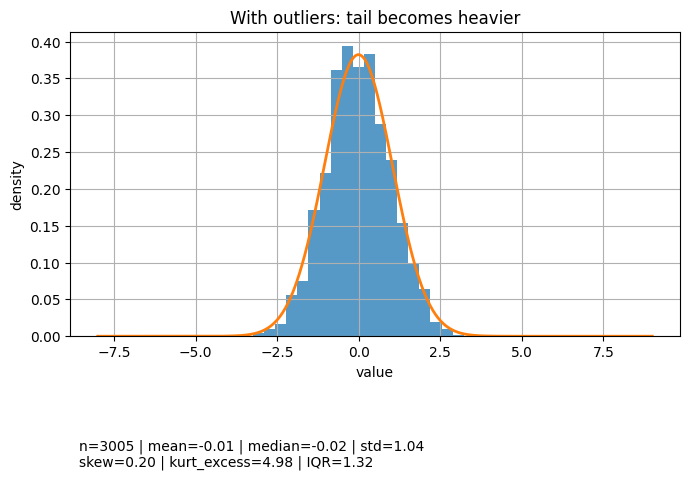

base stats : {'n': 3000, 'mean': -0.010795174408544217, 'median': -0.024065269961001605, 'std(sample)': 0.9944546681292313, 'skew': -0.010876690121529769, 'kurtosis_excess': 0.028807284943789035, 'q1': -0.664305694029447, 'q3': 0.6568335579517661, 'iqr': 1.321139251981213}
mixed stats: {'n': 3005, 'mean': -0.007782204068430168, 'median': -0.023728192105893674, 'std(sample)': 1.0438136407099545, 'skew': 0.1982787197783556, 'kurtosis_excess': 4.983107234346381, 'q1': -0.6653253587512, 'q3': 0.6582713983497335, 'iqr': 1.3235967571009335}


In [35]:


# %% [10] 이상치(outlier)와 분포: 꼬리/왜도/첨도를 동시에 흔든다
# 왜 중요?
# - 이상치 몇 개가 평균/표준편차/왜도/첨도를 크게 바꾸며,
# - 정규분포 근사나 분석 결과 해석을 왜곡할 수 있습니다.
#
# 실습 목표:
# - 이상치 추가 전/후를 비교해서 "꼬리"와 "첨도"가 어떻게 달라지는지 확인

base = np.random.normal(0, 1, 3000)
outliers = np.array([7, 8, 9, -7, -8])  # 의도적 극단값
mixed = np.concatenate([base, outliers])

plot_hist_with_pdf_overlay(base, "Base distribution (no extreme outliers)", bins=50, overlay_normal=True)
plot_hist_with_pdf_overlay(mixed, "With outliers: tail becomes heavier", bins=50, overlay_normal=True)

print("base stats :", summary_stats(base))
print("mixed stats:", summary_stats(mixed))

# 관찰 포인트:
# - mixed에서 kurtosis_excess가 base보다 커지는 경향이 있는지
# - 왜도(skew)는 이상치 배치에 따라 커지거나(한쪽 꼬리), 0에 가까울 수도(양쪽 꼬리) 있습니다.


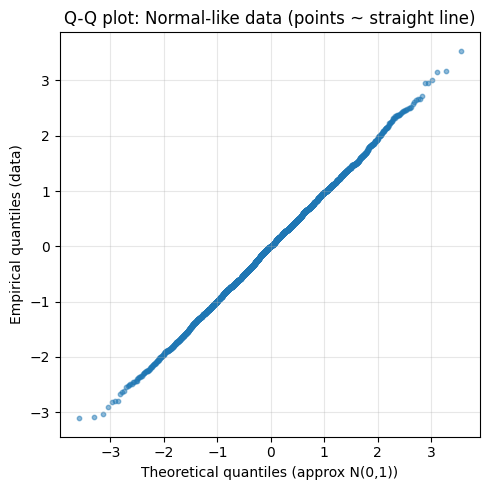

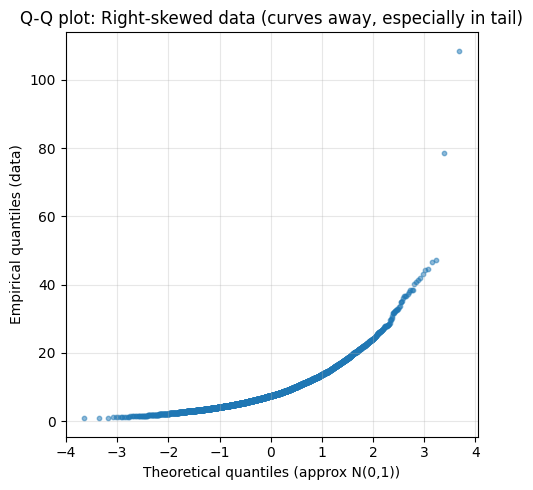

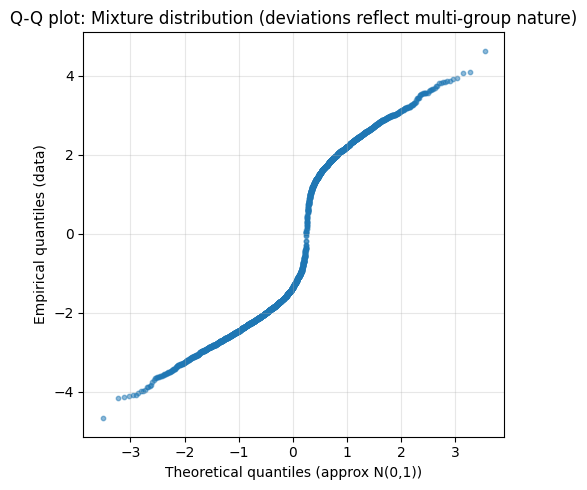

In [36]:


# %% [11] Q-Q plot: 경험적 분포 vs 이론적 분포를 '직접 비교'하는 그래프
# Q-Q plot은 이렇게 묻습니다:
# "이 데이터의 분위수(quantile)들이, 정규분포 분위수와 얼마나 닮았나?"
#
# 해석 기본:
# - 점들이 대각선(직선) 근처에 있으면: 정규와 비슷(특히 중앙부)
# - 꼬리에서 크게 휘면: 꼬리 두꺼움/왜도/이상치/혼합분포 등의 신호일 수 있음
#
# 주의:
# - 여기서는 scipy 없이 "정규 분위수"를 근사하기 위해 큰 표준정규 샘플을 사용합니다.
# - 교육/시각화 목적에는 충분하고, 정밀 분석은 다음 회차에서 scipy를 쓰는 버전으로 확장 가능합니다.

def qq_plot_like(x, title, z_pool_size=300000):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    x_sorted = np.sort(x)
    n = len(x_sorted)

    # 이론적(정규) 분위수 근사: 표준정규를 크게 샘플링해서 분위수로 사용
    z = np.random.normal(0, 1, z_pool_size)
    probs = (np.arange(1, n + 1) - 0.5) / n
    z_q = np.quantile(z, probs)

    plt.figure(figsize=(5, 5))
    plt.scatter(z_q, x_sorted, alpha=0.5, s=10)
    plt.title(title)
    plt.xlabel("Theoretical quantiles (approx N(0,1))")
    plt.ylabel("Empirical quantiles (data)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 정규에 가까운 데이터 vs 비정규 데이터 비교
qq_plot_like(emp1, "Q-Q plot: Normal-like data (points ~ straight line)")
qq_plot_like(right_skew, "Q-Q plot: Right-skewed data (curves away, especially in tail)")
qq_plot_like(emp2, "Q-Q plot: Mixture distribution (deviations reflect multi-group nature)")




=== Example 1 (Normal-like) ===
n=3000
mean=-0.008 | median=0.002 | approx_mode=0.014
std(sample)=0.973 | IQR=1.331
skew=0.010 | kurtosis_excess=-0.033
- 힌트(해석 문장 만들기):
  1) 왜도 부호로 '꼬리 방향'을 말해보세요(+, -, 0 근처).
  2) mean과 median의 상대적 크기로 '평균이 끌렸는지' 말해보세요.
  3) kurtosis_excess가 큰 편이면 '극단값/두꺼운 꼬리' 가능성을 언급해보세요.


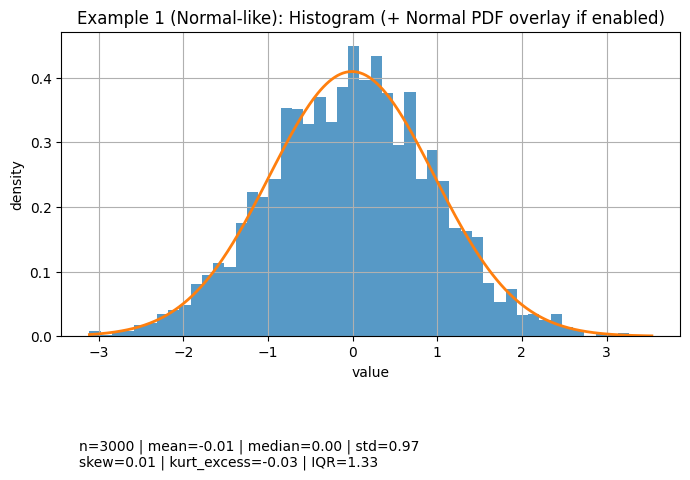

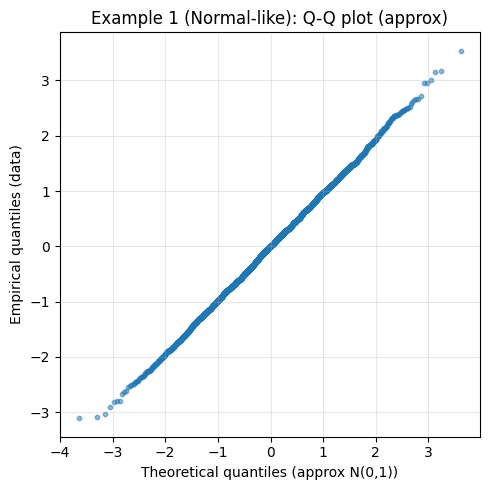


=== Example 2 (Right-skewed) ===
n=4000
mean=8.928 | median=7.452 | approx_mode=5.324
std(sample)=6.026 | IQR=6.346
skew=3.099 | kurtosis_excess=27.010
- 힌트(해석 문장 만들기):
  1) 왜도 부호로 '꼬리 방향'을 말해보세요(+, -, 0 근처).
  2) mean과 median의 상대적 크기로 '평균이 끌렸는지' 말해보세요.
  3) kurtosis_excess가 큰 편이면 '극단값/두꺼운 꼬리' 가능성을 언급해보세요.


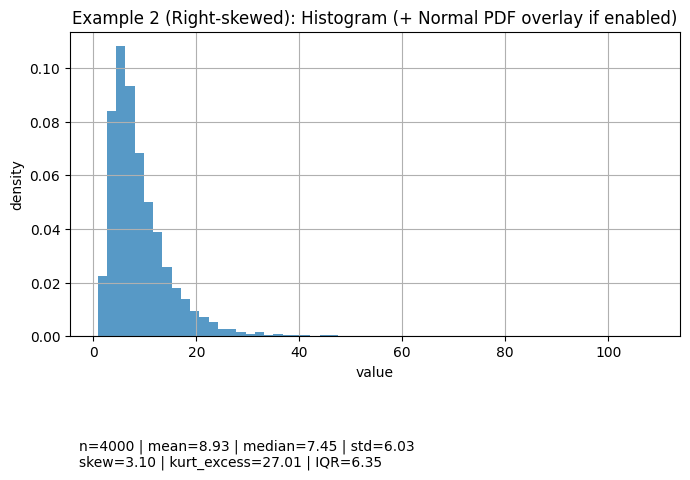

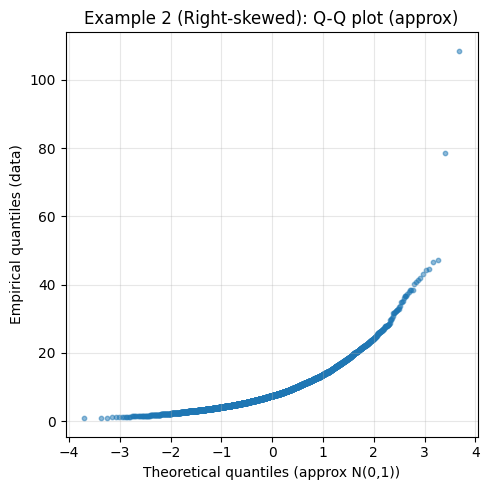


=== Example 3 (With Outliers) ===
n=3005
mean=-0.008 | median=-0.024 | approx_mode=-0.492
std(sample)=1.044 | IQR=1.324
skew=0.198 | kurtosis_excess=4.983
- 힌트(해석 문장 만들기):
  1) 왜도 부호로 '꼬리 방향'을 말해보세요(+, -, 0 근처).
  2) mean과 median의 상대적 크기로 '평균이 끌렸는지' 말해보세요.
  3) kurtosis_excess가 큰 편이면 '극단값/두꺼운 꼬리' 가능성을 언급해보세요.


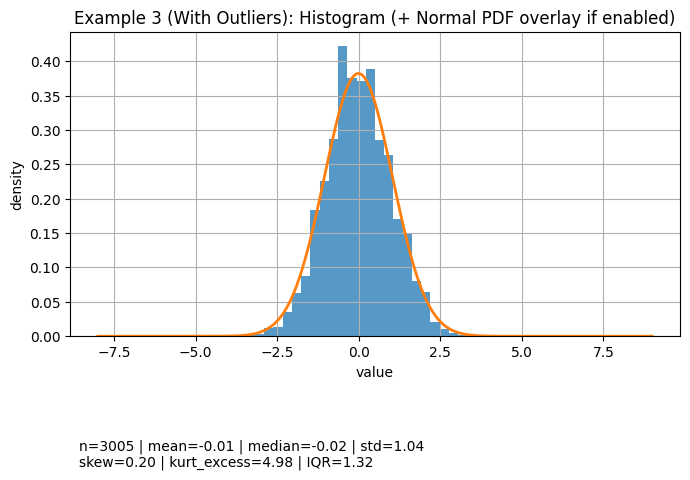

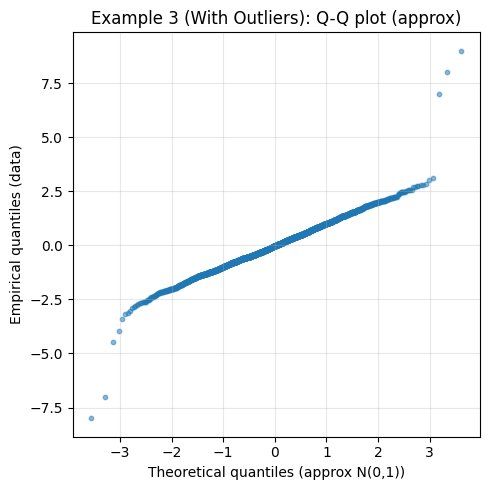

In [37]:

# %% [12] (미션) 학생 실습: "분포를 말로 설명"하기 위한 자동 출력 템플릿
# 수업에서 가장 중요한 건 "정답 맞히기"보다 "근거를 말로 설명"하는 능력입니다.
#
# 아래 함수는 그래프와 요약 통계를 함께 출력해,
# 학생이 다음 문장을 만들도록 돕습니다.
# 1) 대칭/비대칭(왜도 부호)
# 2) 평균 vs 중앙값 비교(평균이 끌리는지)
# 3) 꼬리/극단값 가능성(첨도)
# 4) 정규 근사 가능성(히스토그램+PDF, Q-Q plot)

def explain_distribution(x, name, bins=50, overlay_normal=True):
    stats = summary_stats(x)
    mode_approx = approx_mode_from_hist(x, bins=bins)

    print(f"\n=== {name} ===")
    print(f"n={stats['n']}")
    print(f"mean={stats['mean']:.3f} | median={stats['median']:.3f} | approx_mode={mode_approx:.3f}")
    print(f"std(sample)={stats['std(sample)']:.3f} | IQR={stats['iqr']:.3f}")
    print(f"skew={stats['skew']:.3f} | kurtosis_excess={stats['kurtosis_excess']:.3f}")
    print("- 힌트(해석 문장 만들기):")
    print("  1) 왜도 부호로 '꼬리 방향'을 말해보세요(+, -, 0 근처).")
    print("  2) mean과 median의 상대적 크기로 '평균이 끌렸는지' 말해보세요.")
    print("  3) kurtosis_excess가 큰 편이면 '극단값/두꺼운 꼬리' 가능성을 언급해보세요.")

    plot_hist_with_pdf_overlay(x, f"{name}: Histogram (+ Normal PDF overlay if enabled)", bins=bins, overlay_normal=overlay_normal)
    qq_plot_like(x, f"{name}: Q-Q plot (approx)", z_pool_size=250000)

# 예시 실행
explain_distribution(emp1, "Example 1 (Normal-like)", bins=50, overlay_normal=True)
explain_distribution(right_skew, "Example 2 (Right-skewed)", bins=60, overlay_normal=False)
explain_distribution(mixed, "Example 3 (With Outliers)", bins=60, overlay_normal=True)

# (학생 과제 아이디어)
# - explain_distribution()에 자신이 만든 데이터(예: 혼합분포, 이상치 포함, 왼쪽 왜도 등)를 넣고,
#   출력된 숫자와 그래프를 근거로 '분포 설명 문장 3개'를 작성하게 해보세요.
